# 5-minute tour

**Who it's for:** everyone — this single example serves both worlds. Computational neuroscientists get a working spiking network; brain-inspired-computing readers get the exact same model that is later trained with gradients.

**What you'll learn:** how to build an excitatory–inhibitory (E/I) balanced network, run it efficiently with `brainstate.transform`, and plot a spike raster — the "aha" that shows what `brainpy.state` does.

## Imports

Everything comes from the public ecosystem surface: `brainpy.state` for the models, `brainstate` for state + compilation, `braintools` for initializers, and `brainunit` for physical units.

In [1]:
import brainpy
import brainstate
import braintools
import brainunit as u
import matplotlib.pyplot as plt

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## The model: a COBA E/I network

We build the classic conductance-based (COBA) balanced network of Vogels & Abbott (2005) / Brette et al. (2007): 3200 excitatory and 800 inhibitory leaky integrate-and-fire neurons, sparsely and recurrently connected.

Notice the structure of each projection — this is the keystone **AlignPost** design (`AlignPostProj`), built from four roles:

- `comm` — the connection matrix (here a sparse event-driven connectivity, `EventFixedProb`),
- `syn` — the synapse dynamics (`Expon.desc`, an exponential synapse *describer*),
- `out` — how the synapse drives the target (`COBA.desc`, conductance-based),
- `post` — the postsynaptic population.

We cover *why* this shape matters in [the keystone chapter](/concepts/alignpre-alignpost).

In [2]:
class EINet(brainstate.nn.Module):
    def __init__(self):
        super().__init__()
        self.n_exc, self.n_inh = 3200, 800
        self.num = self.n_exc + self.n_inh
        # One shared population of refractory LIF neurons.
        self.N = brainpy.state.LIFRef(
            self.num,
            V_rest=-60. * u.mV, V_th=-50. * u.mV, V_reset=-60. * u.mV,
            tau=20. * u.ms, tau_ref=5. * u.ms,
            V_initializer=braintools.init.Normal(-55., 2., unit=u.mV),
        )
        # Excitatory projection (reversal potential 0 mV).
        self.E = brainpy.state.AlignPostProj(
            comm=brainstate.nn.EventFixedProb(
                self.n_exc, self.num, conn_num=0.02, conn_weight=0.6 * u.mS),
            syn=brainpy.state.Expon.desc(self.num, tau=5. * u.ms),
            out=brainpy.state.COBA.desc(E=0. * u.mV),
            post=self.N,
        )
        # Inhibitory projection (reversal potential -80 mV).
        self.I = brainpy.state.AlignPostProj(
            comm=brainstate.nn.EventFixedProb(
                self.n_inh, self.num, conn_num=0.02, conn_weight=6.7 * u.mS),
            syn=brainpy.state.Expon.desc(self.num, tau=10. * u.ms),
            out=brainpy.state.COBA.desc(E=-80. * u.mV),
            post=self.N,
        )

    def update(self, t, inp):
        with brainstate.environ.context(t=t):
            spk = self.N.get_spike() != 0.
            self.E(spk[:self.n_exc])   # route excitatory spikes
            self.I(spk[self.n_exc:])   # route inhibitory spikes
            self.N(inp)                # advance neurons one step
            return self.N.get_spike()

## Build and initialize

Constructing the module allocates its parameters; `brainstate.nn.init_all_states` then allocates and resets every dynamic state (membrane potentials, synaptic conductances) so the network is ready to run.

In [3]:
net = EINet()
brainstate.nn.init_all_states(net)

EINet(
  n_exc=3200,
  n_inh=800,
  num=4000,
  N=LIFRef(
    in_size=(4000,),
    out_size=(4000,),
    before_updates={
      "(<class 'brainpy.state.Expon'>, (4000,), {'tau': '5. ms'}) // (<class 'brainpy.state.COBA'>, (), {'E': '0. mV'})": _AlignPost(
        syn=Expon(
          in_size=(4000,),
          out_size=(4000,),
          tau=Quantity(5., "ms"),
          g_initializer=Constant(value=0. mS),
          g=HiddenState(
            value=Quantity(~float32[4000], "mS")
          )
        ),
        out=COBA(
          E=Quantity(0., "mV")
        )
      ),
      "(<class 'brainpy.state.Expon'>, (4000,), {'tau': '10. ms'}) // (<class 'brainpy.state.COBA'>, (), {'E': '-80. mV'})": _AlignPost(
        syn=Expon(
          in_size=(4000,),
          out_size=(4000,),
          tau=Quantity(10., "ms"),
          g_initializer=Constant(value=0. mS),
          g=HiddenState(
            value=Quantity(~float32[4000], "mS")
          )
        ),
        out=COBA(
          E=Quan

## Run the simulation

We advance the network for 1000 ms with a constant external drive.

We **never** step the model with a bare Python `for` loop. `brainstate.transform.for_loop` lowers the *entire* time loop into a single compiled XLA program — the body is traced once, fused, and the per-step outputs are stacked for you. (For other shapes of work use `scan`, `jit`, or the `checkpointed_*` variants.)

In [4]:
with brainstate.environ.context(dt=0.1 * u.ms):
    times = u.math.arange(0. * u.ms, 1000. * u.ms, brainstate.environ.get_dt())
    spikes = brainstate.transform.for_loop(
        lambda t: net.update(t, 20. * u.mA), times)

## Visualize: a spike raster

`spikes` has shape `[time, neuron]`. We find where spikes occurred and scatter neuron index against time.

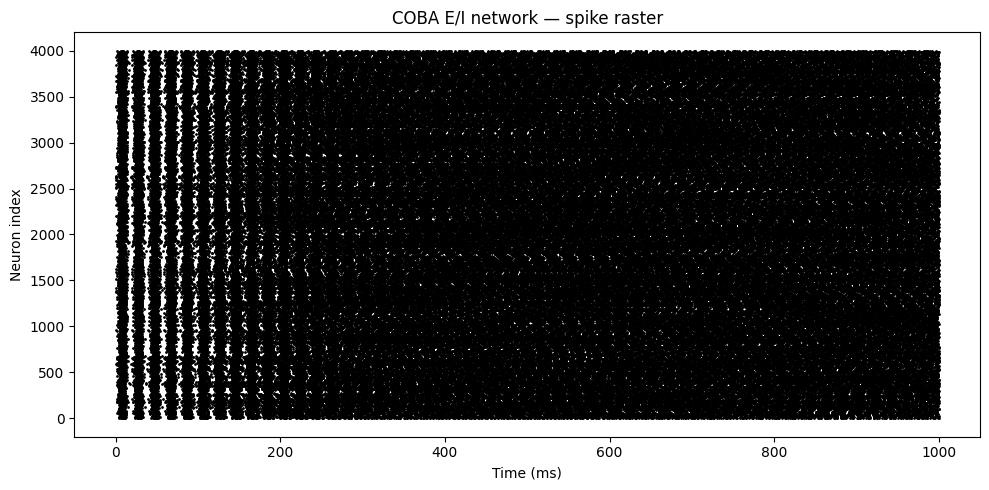

In [5]:
t_idx, n_idx = u.math.where(spikes)
plt.figure(figsize=(10, 5))
plt.scatter(times[t_idx].to_decimal(u.ms), n_idx, s=1, color='black')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.title('COBA E/I network — spike raster')
plt.tight_layout()
plt.show()

## See also

- :doc:`/concepts/index` — the Core Concepts spine: why this design works, ending in the keystone :doc:`AlignPre/AlignPost chapter </concepts/alignpre-alignpost>`.
- :doc:`/get-started/mental-model` — the four big ideas behind the code you just ran.
- :doc:`/brainpy-style/index` — go deeper with the BrainPy-style tutorials and how-to guides, including :doc:`the E/I network tutorial </brainpy-style/tutorials/03-ei-balanced-network>`.